<a href="https://colab.research.google.com/github/samihannn/aml-exps-samihan/blob/main/AML_Exp_7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

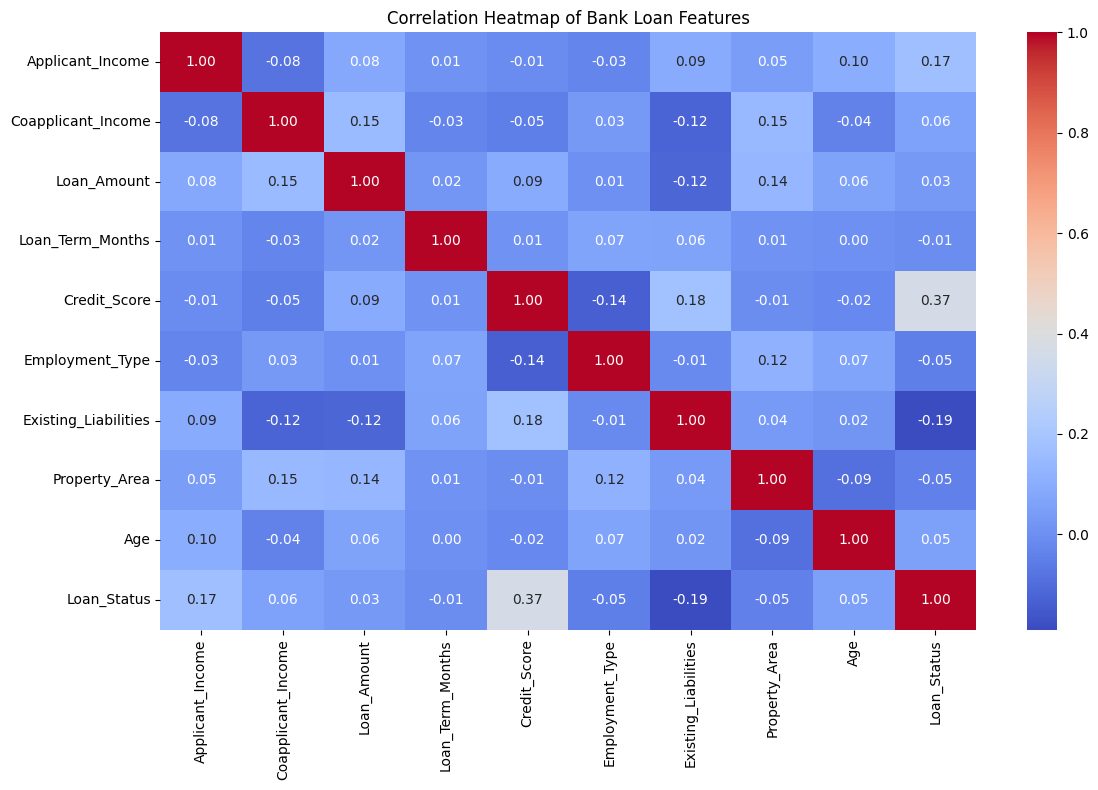

Starting SVM Training and Tuning...

--- Tuning LINEAR Kernel ---
Best Parameters: {'C': 10, 'gamma': 1}
Accuracy: 80.00%
Confusion Matrix:
[[22  4]
 [ 2  2]]
              precision    recall  f1-score   support

           0       0.92      0.85      0.88        26
           1       0.33      0.50      0.40         4

    accuracy                           0.80        30
   macro avg       0.62      0.67      0.64        30
weighted avg       0.84      0.80      0.82        30


--- Tuning RBF Kernel ---
Best Parameters: {'C': 100, 'gamma': 0.01}
Accuracy: 86.67%
Confusion Matrix:
[[24  2]
 [ 2  2]]
              precision    recall  f1-score   support

           0       0.92      0.92      0.92        26
           1       0.50      0.50      0.50         4

    accuracy                           0.87        30
   macro avg       0.71      0.71      0.71        30
weighted avg       0.87      0.87      0.87        30


--- Tuning POLY Kernel ---
Best Parameters: {'C': 1, 'gamma': 

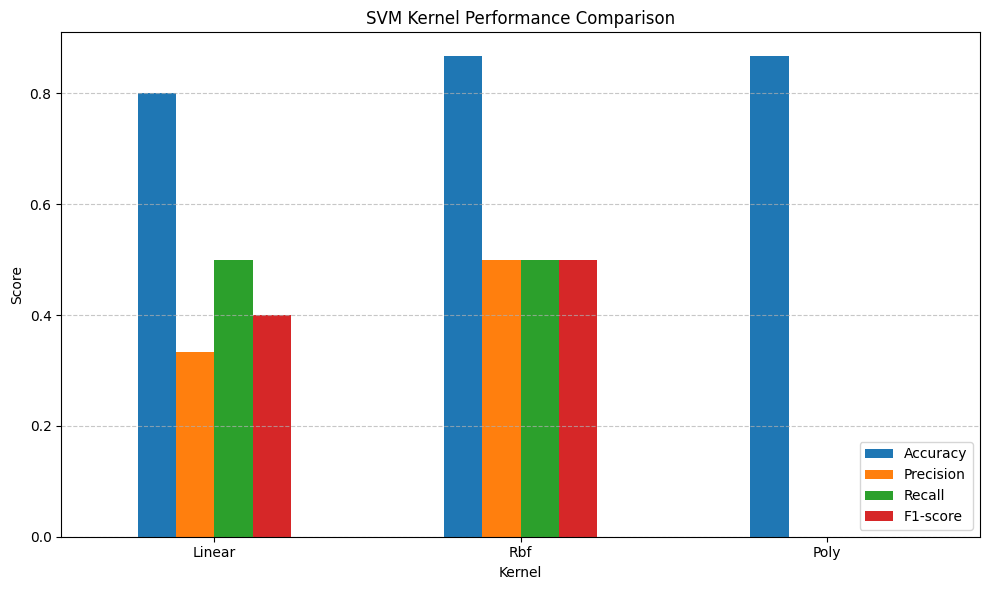

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report, precision_score, recall_score, f1_score

df = pd.read_csv('Bank_Loan_Approval_Dataset.csv')

le_emp = LabelEncoder()
df['Employment_Type'] = le_emp.fit_transform(df['Employment_Type'])

le_prop = LabelEncoder()
df['Property_Area'] = le_prop.fit_transform(df['Property_Area'])

X = df.drop('Loan_Status', axis=1)
y = df['Loan_Status']

plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Bank Loan Features')
plt.tight_layout()
plt.show()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

kernels = ['linear', 'rbf', 'poly']
param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': [1, 0.1, 0.01, 0.001],
}

results = []

print("Starting SVM Training and Tuning...")

for kernel in kernels:
    print(f"\n--- Tuning {kernel.upper()} Kernel ---")

    grid = GridSearchCV(SVC(kernel=kernel), param_grid, refit=True, verbose=0, cv=5)
    grid.fit(X_train, y_train)

    y_pred = grid.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    cm = confusion_matrix(y_test, y_pred)

    results.append({
        'Kernel': kernel.capitalize(),
        'Best C': grid.best_params_['C'],
        'Best Gamma': grid.best_params_['gamma'],
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1-score': f1
    })

    print(f"Best Parameters: {grid.best_params_}")
    print(f"Accuracy: {acc:.2%}")
    print(f"Confusion Matrix:\n{cm}")
    print(classification_report(y_test, y_pred, zero_division=0))

results_df = pd.DataFrame(results)
print("\n--- Kernel Performance Comparison Table ---")
print(results_df)

results_df.set_index('Kernel')[['Accuracy', 'Precision', 'Recall', 'F1-score']].plot(kind='bar', figsize=(10, 6))
plt.title('SVM Kernel Performance Comparison')
plt.ylabel('Score')
plt.xticks(rotation=0)
plt.legend(loc='lower right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()